In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, math, json, time, random
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
from tqdm.notebook import tqdm

from data_loading import *
from loss_funcs import *

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")  # I have a 3090
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")


PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [2]:
weather_cols_all = ['temperature_2m',
       'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
       'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']

other_cols = [ # these are not static
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
# this data has a data column and categorical columns are kept intact and will need to be handled.
# "time_idx" is already built in train, val and test and is continuous through them
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val : (293880, 38)
test: (295430, 38)


In [4]:
# # If a model cant handle categorical columns natively, or through embedings use this data
# # It has no datetime column and all columns are numeric, as all cat column were ohe
# # GROUP_COL is the only exception, and is not ohe. Ohe it before training
# print("Loading train …")
# train = load_and_prepare(TRAIN_PATH_OHE)
#
# print("Loading val   …")
# val = load_and_prepare(VAL_PATH_OHE)
#
# print("Loading test  …")
# test = load_and_prepare(TEST_PATH_OHE)
#
# print(f"train: {train.shape}")
# print(f"val  : {val.shape}")
# print(f"test : {test.shape}")

In [5]:
# this cell samples locations, I'll use it if training takes too long, otherwise don't touch it

TARGET_STATIONS = 395

station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [6]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14615


## Crossformer training

The cells below adapt the notebook to train **Crossformer** ("Transformer Utilizing
Cross-Dimension Dependency for Multivariate Time Series Forecasting", Zhang & Yan, 2023).

Pipeline (each cell is one logical step):

1. **Config** — hyperparameters and Crossformer-specific settings.
2. **Feature prep** — categorical encoding, scaling, per-station scaler dicts.
3. **Sliding-window dataset** — produces `(x_past, x_future_exog, y_future, prices)` tuples.
4. **Differentiable money loss** — torch port of `money_pct` from `loss_funcs.py`.
5. **Crossformer model** — DSW segment embedding, Two-Stage Attention encoder, decoder with routers.
6. **Training loop** — money-based loss, AMP, checkpointing, MLflow logging.
7. **Recursive inference** — rolls 48-hour forecasts across val/test month.
8. **Metrics & logging** — money, money_pct, MAE, RMSE, MAPE, SMAPE, bias.


In [7]:
# === Crossformer config =====================================================
# These are the hyperparameters that drive the rest of the notebook.

@dataclass
class CrossformerConfig:
    # Window sizes (hours, since data is hourly)
    in_len: int = 168          # encoder lookback: 7 days
    out_len: int = 48          # prediction horizon: 2 days
    seg_len: int = 24          # segment length for DSW embedding (1 day per segment)

    # Crossformer architecture
    d_model: int = 128         # embedding dim per segment
    d_ff: int = 256            # FFN inner dim
    n_heads: int = 4
    e_layers: int = 3          # encoder TSA layers
    win_size: int = 2          # segment-merge window between encoder layers
    factor: int = 10           # router count for cross-dimension attention
    dropout: float = 0.1

    # Training
    batch_size: int = 64
    epochs: int = 15
    lr: float = 1e-4
    weight_decay: float = 1e-5
    grad_clip: float = 1.0
    amp: bool = True
    num_workers: int = 4

    # Loss mixing: money_pct can be flat at small errors; blend a small MAE term
    # to give the optimizer a non-zero gradient inside the +-10% deadband.
    smape_aux_weight: float = 0.3

CFG = CrossformerConfig()
print(CFG)


CrossformerConfig(in_len=168, out_len=48, seg_len=24, d_model=128, d_ff=256, n_heads=4, e_layers=3, win_size=2, factor=10, dropout=0.1, batch_size=64, epochs=15, lr=0.0001, weight_decay=1e-05, grad_clip=1.0, amp=True, num_workers=4, smape_aux_weight=0.1)


In [8]:
# === Feature preparation ====================================================
# Strategy:
#   * Treat each gas station (GROUP_COL) as an independent multivariate
#     time series; Crossformer will attend across variables AND across time.
#   * Categoricals (eic_code, dso_desc, station_type, oblast) -> integer codes,
#     fed through nn.Embedding inside the model and broadcast across time.
#     This keeps the variable count low (vs OHE) and lets the model learn
#     a per-station signature.
#   * Calendar columns (Month, Day, Hour, day_of_week, season) -> sin/cos
#     cyclical encoding. Two channels per cyclic feature, fully numeric,
#     no embedding needed -- much cheaper than treating Hour as 24 OHE columns.
#   * Continuous columns (weather, prices, capacity, target) -> z-score scaled
#     using TRAIN statistics only (no leakage).
#   * Target is per-station scaled: each station has its own mean/std so the
#     model output range is comparable across very different stations.

# --- Cyclical encoding for calendar ---
CYCLIC_PERIODS = {"Month": 12, "Day": 31, "Hour": 24, "day_of_week": 7, "season": 4}

# Some calendar columns may arrive as strings (e.g. season = 'winter'/'spring'/...).
# Build train-derived mappings once and reuse for val/test so encodings are consistent.
SEASON_ORDER = ["winter", "spring", "summer", "fall", "autumn"]  # 'fall'/'autumn' both map ok

def _to_numeric_calendar(series: pd.Series, col: str, mapping) -> tuple[pd.Series, dict]:
    """Coerce a calendar column to numeric. If non-numeric, build/reuse a mapping."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(np.float32), mapping or {}
    s = series.astype(str).str.lower().str.strip()
    if mapping is None:
        # Prefer a stable order if values look like seasons; otherwise use sorted unique
        uniq = sorted(s.unique().tolist())
        if col == "season":
            ordered = [v for v in SEASON_ORDER if v in uniq] + [v for v in uniq if v not in SEASON_ORDER]
            mapping = {v: i for i, v in enumerate(ordered)}
        else:
            mapping = {v: i for i, v in enumerate(uniq)}
    coded = s.map(mapping).fillna(0).astype(np.float32)
    return coded, mapping

# Persist any string->int mappings learned on train so val/test use the same codes.
calendar_str_maps: Dict[str, dict] = {}

def add_cyclical(df: pd.DataFrame, fit: bool) -> pd.DataFrame:
    for col, period in CYCLIC_PERIODS.items():
        existing = calendar_str_maps.get(col)
        v_num, mapping = _to_numeric_calendar(df[col], col, None if fit else existing)
        if fit and mapping:
            calendar_str_maps[col] = mapping
        # Subtract min so the phase is 0-aligned (Day starts at 1, others at 0).
        v = v_num - v_num.min()
        df[f"{col}_sin"] = np.sin(2 * np.pi * v / period).astype(np.float32)
        df[f"{col}_cos"] = np.cos(2 * np.pi * v / period).astype(np.float32)
    return df

train = add_cyclical(train, fit=True)
val   = add_cyclical(val,   fit=False)
test  = add_cyclical(test,  fit=False)

if calendar_str_maps:
    print("String-coded calendar columns:", {k: v for k, v in calendar_str_maps.items()})

CYCLIC_COLS = [f"{c}_{s}" for c in CYCLIC_PERIODS for s in ("sin", "cos")]

# --- Categorical -> integer codes (fit on train, apply to val/test) ---
EMBED_CAT_COLS = ["eic_code", "dso_desc", "station_type", "oblast"]

cat_vocab: Dict[str, Dict] = {}
for col in EMBED_CAT_COLS:
    uniq = pd.Index(train[col].astype(str).unique())
    mapping = {v: i + 1 for i, v in enumerate(uniq)}  # 0 reserved for unknown
    cat_vocab[col] = {"map": mapping, "size": len(mapping) + 1}
    for df in (train, val, test):
        df[f"{col}_code"] = df[col].astype(str).map(mapping).fillna(0).astype(np.int64)

print("Categorical vocab sizes:", {c: cat_vocab[c]["size"] for c in EMBED_CAT_COLS})

# --- Continuous feature lists ---
CONT_COLS_TIME = (
    weather_cols_all
    + ["dam_price", "buy_bm_price", "sell_bm_price", "max_power", "max_solar", "max_ev"]
    + CYCLIC_COLS
)
# These are static numeric (lat/lon) -- broadcast across time inside the model
CONT_COLS_STATIC = ["latitude", "longitude"]

# --- Scaling: train-only statistics ---
class StandardScaler1D:
    def __init__(self, eps: float = 1e-6):
        self.mean: Optional[np.ndarray] = None
        self.std: Optional[np.ndarray] = None
        self.eps = eps
    def fit(self, x: np.ndarray):
        self.mean = np.nanmean(x, axis=0).astype(np.float32)
        self.std  = np.nanstd(x, axis=0).astype(np.float32) + self.eps
        return self
    def transform(self, x: np.ndarray) -> np.ndarray:
        return ((x - self.mean) / self.std).astype(np.float32)

cont_time_scaler = StandardScaler1D().fit(train[CONT_COLS_TIME].values)
cont_static_scaler = StandardScaler1D().fit(train[CONT_COLS_STATIC].values)

# Per-station target scaler -- crucial because stations differ in magnitude.
target_scalers: Dict[str, Tuple[float, float]] = {}
for sid, gdf in train.groupby(GROUP_COL):
    m = float(gdf[Y_COL].mean())
    s = float(gdf[Y_COL].std() + 1e-6)
    target_scalers[sid] = (m, s)

# Stations missing in train fall back to global stats
GLOBAL_TGT_MEAN = float(train[Y_COL].mean())
GLOBAL_TGT_STD  = float(train[Y_COL].std() + 1e-6)

print(f"# stations with target scaler: {len(target_scalers)}")
print(f"Continuous time-varying features: {len(CONT_COLS_TIME)}")
print(f"Static continuous features      : {len(CONT_COLS_STATIC)}")

String-coded calendar columns: {'season': {'1': 0, '2': 1, '3': 2, '4': 3}}
Categorical vocab sizes: {'eic_code': 396, 'dso_desc': 28, 'station_type': 8, 'oblast': 24}
# stations with target scaler: 395
Continuous time-varying features: 34
Static continuous features      : 2


In [9]:
# === Sliding-window dataset =================================================
# Each sample is a (lookback, horizon) window from a single station.
# Returned tensors:
#   x_past_target : [in_len]                  scaled past target
#   x_past_cont   : [in_len, n_cont_time]     scaled time-varying continuous
#   x_fut_cont    : [out_len, n_cont_time]    same channels, future window (known exog)
#   x_static_cont : [n_cont_static]           scaled lat/lon
#   x_cat_codes   : [n_cat]                   integer codes (constant per station)
#   y_future      : [out_len]                 scaled future target
#   y_future_raw  : [out_len]                 unscaled (for money loss)
#   prices        : [out_len, 3]              dam_price, sell_bm_price, buy_bm_price (raw)
#   tgt_mean,std  : scalars                   so we can invert in loss

class StationWindowDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        in_len: int,
        out_len: int,
        stride: int = 1,
        is_train: bool = True,
    ):
        self.in_len = in_len
        self.out_len = out_len
        self.is_train = is_train

        # Pre-extract per-station numpy blocks for speed -- avoid pandas slicing in __getitem__.
        self.blocks: List[Dict] = []
        self.index: List[Tuple[int, int]] = []  # (block_idx, start_t)

        for sid, gdf in df.sort_values([GROUP_COL, "time_idx"]).groupby(GROUP_COL, sort=False):
            n = len(gdf)
            if n < in_len + out_len:
                continue
            mean, std = target_scalers.get(sid, (GLOBAL_TGT_MEAN, GLOBAL_TGT_STD))

            block = {
                "sid": sid,
                "y_raw":      gdf[Y_COL].values.astype(np.float32),
                "y_scaled":   ((gdf[Y_COL].values - mean) / std).astype(np.float32),
                "cont_time":  cont_time_scaler.transform(gdf[CONT_COLS_TIME].values),
                "cont_static":cont_static_scaler.transform(gdf[CONT_COLS_STATIC].iloc[0:1].values)[0],
                "cat_codes":  np.array(
                    [int(gdf[f"{c}_code"].iloc[0]) for c in EMBED_CAT_COLS],
                    dtype=np.int64,
                ),
                "prices":     gdf[["dam_price", "sell_bm_price", "buy_bm_price"]].values.astype(np.float32),
                "time_idx":   gdf["time_idx"].values.astype(np.int64),
                "mean":       np.float32(mean),
                "std":        np.float32(std),
            }
            b_idx = len(self.blocks)
            self.blocks.append(block)
            # Sliding window starts
            last_start = n - in_len - out_len
            for t in range(0, last_start + 1, stride):
                self.index.append((b_idx, t))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        b_idx, t = self.index[idx]
        b = self.blocks[b_idx]
        s_in, s_out = self.in_len, self.out_len
        e1 = t + s_in
        e2 = e1 + s_out

        return {
            "x_past_target": torch.from_numpy(b["y_scaled"][t:e1]),
            "x_past_cont":   torch.from_numpy(b["cont_time"][t:e1]),
            "x_fut_cont":    torch.from_numpy(b["cont_time"][e1:e2]),
            "x_static_cont": torch.from_numpy(b["cont_static"]),
            "x_cat_codes":   torch.from_numpy(b["cat_codes"]),
            "y_future":      torch.from_numpy(b["y_scaled"][e1:e2]),
            "y_future_raw":  torch.from_numpy(b["y_raw"][e1:e2]),
            "prices":        torch.from_numpy(b["prices"][e1:e2]),
            "tgt_mean":      torch.tensor(b["mean"]),
            "tgt_std":       torch.tensor(b["std"]),
        }


# Building train uses dense stride; val/test only used as anchors here -- the real
# val/test evaluation is the recursive rolling forecast further down.
print("Building datasets ...")
train_ds = StationWindowDataset(train, CFG.in_len, CFG.out_len, stride=CFG.out_len, is_train=True)
val_ds   = StationWindowDataset(val,   CFG.in_len, CFG.out_len, stride=CFG.out_len, is_train=False)

print(f"train windows: {len(train_ds):,}")
print(f"val   windows: {len(val_ds):,}")

# Replace the train_loader / val_loader construction with this
train_loader = DataLoader(
    train_ds, batch_size=CFG.batch_size, shuffle=True,
    num_workers=0,                      # <-- single-process, no fork overhead
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.batch_size, shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

Building datasets ...
train windows: 93,805
val   windows: 4,740


In [10]:
# === Differentiable money loss (torch port) =================================
# Mirrors loss_funcs.money / money_pct exactly -- piecewise-linear in y_pred,
# fully differentiable via torch.where (sub-gradient at zero is fine in practice).
#
# Inputs:
#   y_true, y_pred       : [B, T]   real units (kWh)
#   price                : [B, T]   dam_price       (UAH per MWh, /1000 -> per kWh)
#   selling_price        : [B, T]   sell_bm_price
#   buying_price         : [B, T]   buy_bm_price
# Returns scalar loss.

def money_loss_torch(
    y_true: torch.Tensor,
    y_pred: torch.Tensor,
    price: torch.Tensor,
    selling_price: torch.Tensor,
    buying_price: torch.Tensor,
    pct: bool = True,
    eps: float = 1e-6,
) -> torch.Tensor:
    p   = price / 1000.0
    sp  = selling_price / 1000.0
    bp  = buying_price / 1000.0

    min_spend  = y_true * p
    ordered    = y_pred * p
    diff       = y_pred - y_true

    real_spend = (
        ordered
        - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
        - torch.where(diff < 0, bp * diff, torch.zeros_like(diff))
    )
    excess = real_spend - min_spend  # always >= 0 in expectation

    total = excess.sum()
    if not pct:
        return total
    denom = (min_spend.sum().abs() / 100.0) + eps
    return total / denom


def combined_loss(
    y_pred_scaled: torch.Tensor,
    y_true_scaled: torch.Tensor,        # kept for API compatibility, unused now
    y_true_raw: torch.Tensor,
    prices: torch.Tensor,
    tgt_mean: torch.Tensor,
    tgt_std: torch.Tensor,
    smape_weight: float = 0.1,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """Money_pct + small SMAPE auxiliary term, both backprop'd.

    Money_pct is the actual business objective. SMAPE provides a
    non-zero, scale-free gradient inside the implicit money_pct deadband
    and stabilizes early training; weight is small so it doesn't dominate.
    SMAPE is computed on raw kWh (always >= 0); on z-scored values the
    denominator crosses zero and the loss explodes.
    """
    # Invert per-station scaling so both losses see real kWh.
    mean = tgt_mean.unsqueeze(1)  # [B, 1]
    std  = tgt_std.unsqueeze(1)
    y_pred_raw = y_pred_scaled * std + mean

    money_pct = money_loss_torch(
        y_true_raw, y_pred_raw,
        prices[..., 0], prices[..., 1], prices[..., 2],
        pct=True,
    )

    # SMAPE in % on raw kWh. eps in the denominator avoids div-by-zero
    # at idle hours where both true and predicted consumption are ~0.
    eps = 1e-6
    smape_pct = 100.0 * torch.mean(
        2.0 * torch.abs(y_pred_raw - y_true_raw)
        / (torch.abs(y_pred_raw) + torch.abs(y_true_raw) + eps)
    )

    loss = money_pct + smape_weight * smape_pct

    return loss, {
        "money_pct": float(money_pct.detach()),
        "smape": float(smape_pct.detach()),
    }


In [11]:
# === Crossformer model ======================================================
# Reference: Zhang & Yan, "Crossformer: Transformer Utilizing Cross-Dimension
# Dependency for Multivariate Time Series Forecasting", ICLR 2023.
#
# Key components implemented below:
#
# 1. DSWEmbedding (Dimension-Segment-Wise embedding):
#    Splits each variable's time series into non-overlapping segments of
#    length seg_len and projects each segment to d_model. The output has
#    shape [B, D, S, d_model] where D = num variables, S = num segments.
#    This is what gives Crossformer its "patch per variable" structure.
#
# 2. TwoStageAttentionLayer (TSA):
#    Stage A -- cross-time attention: standard multi-head attention along
#    the segment axis, applied independently per variable. Captures
#    temporal dependencies within each series.
#    Stage B -- cross-dimension attention via routers: instead of full
#    O(D^2) attention across variables, a small set of `factor` learnable
#    router queries gather information from all variables, then redistribute.
#    Two attentions: variables -> routers (gather), routers -> variables
#    (distribute). Cost is O(D * factor) instead of O(D^2).
#
# 3. SegmentMerge:
#    Between encoder layers, concatenate `win_size` consecutive segments
#    along d_model and project back to d_model. Halves (by win_size) the
#    segment count -> hierarchical multi-scale features.
#
# 4. CrossformerDecoder:
#    Cross-attention from learnable output queries to each encoder level,
#    plus its own TSA. Each level outputs a partial prediction (linear head
#    over segments); partial predictions are SUMMED to get the final
#    forecast (residual hierarchical prediction).
#
# Input to the model in this notebook is built from:
#   * past target (1 variable)
#   * time-varying continuous features (CONT_COLS_TIME) -- known in future
#   * static features broadcast across time (lat/lon + categorical embeddings)
# All concatenated along the variable axis -> Crossformer treats them as a
# single multivariate series.

class DSWEmbedding(nn.Module):
    """Per-variable segment embedding."""
    def __init__(self, seg_len: int, d_model: int):
        super().__init__()
        self.seg_len = seg_len
        self.proj = nn.Linear(seg_len, d_model)
        self.pos_seg = None  # built lazily once we know S
        self.pos_var = None  # built lazily once we know D
        self.d_model = d_model

    def _build_pos(self, D: int, S: int, device):
        if self.pos_seg is None or self.pos_seg.shape[1] != S:
            self.pos_seg = nn.Parameter(torch.zeros(1, 1, S, self.d_model, device=device))
            nn.init.trunc_normal_(self.pos_seg, std=0.02)
        if self.pos_var is None or self.pos_var.shape[1] != D:
            self.pos_var = nn.Parameter(torch.zeros(1, D, 1, self.d_model, device=device))
            nn.init.trunc_normal_(self.pos_var, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]   T must be divisible by seg_len
        B, T, D = x.shape
        S = T // self.seg_len
        # -> [B, D, S, seg_len]
        x = x.permute(0, 2, 1).reshape(B, D, S, self.seg_len)
        x = self.proj(x)  # [B, D, S, d_model]
        # Static positional encodings (registered as plain tensors to avoid Parameter on-the-fly)
        return x


class _MHA(nn.Module):
    """Tiny multi-head attention used inside TSA."""
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, q, k, v):
        a, _ = self.attn(q, k, v, need_weights=False)
        x = self.norm1(q + self.drop(a))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class TwoStageAttentionLayer(nn.Module):
    """One TSA block: cross-time then cross-dimension (router) attention."""
    def __init__(self, d_model: int, n_heads: int, factor: int, dropout: float):
        super().__init__()
        self.time_attn = _MHA(d_model, n_heads, dropout)
        # Routers
        self.router = nn.Parameter(torch.zeros(1, factor, d_model))
        nn.init.trunc_normal_(self.router, std=0.02)
        self.dim_send = _MHA(d_model, n_heads, dropout)  # vars -> routers
        self.dim_recv = _MHA(d_model, n_heads, dropout)  # routers -> vars
        self.factor = factor

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, D, S, d_model]
        B, D, S, E = x.shape

        # --- Stage A: cross-time, per variable ---
        # Reshape so each (batch, var) gets its own sequence of length S.
        x_t = x.reshape(B * D, S, E)
        x_t = self.time_attn(x_t, x_t, x_t)
        x = x_t.reshape(B, D, S, E)

        # --- Stage B: cross-dimension via routers, per segment ---
        # Each segment position s gathers info across variables independently.
        x_d = x.permute(0, 2, 1, 3).reshape(B * S, D, E)  # [BS, D, E]
        routers = self.router.expand(B * S, -1, -1)        # [BS, factor, E]
        gathered = self.dim_send(routers, x_d, x_d)        # [BS, factor, E]
        x_d = self.dim_recv(x_d, gathered, gathered)       # [BS, D, E]
        x = x_d.reshape(B, S, D, E).permute(0, 2, 1, 3).contiguous()
        return x


class SegmentMerge(nn.Module):
    """Concat win_size consecutive segments and project back to d_model."""
    def __init__(self, d_model: int, win_size: int):
        super().__init__()
        self.win_size = win_size
        self.proj = nn.Linear(d_model * win_size, d_model)
        self.norm = nn.LayerNorm(d_model * win_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, D, S, E] -> [B, D, S//win, E]
        B, D, S, E = x.shape
        w = self.win_size
        if S % w != 0:
            # pad on the segment dim with the last segment repeated
            pad = w - (S % w)
            x = torch.cat([x, x[:, :, -1:, :].expand(-1, -1, pad, -1)], dim=2)
            S = x.shape[2]
        x = x.reshape(B, D, S // w, w * E)
        x = self.norm(x)
        x = self.proj(x)
        return x


class CrossformerEncoder(nn.Module):
    def __init__(self, e_layers, d_model, n_heads, factor, win_size, dropout):
        super().__init__()
        self.layers = nn.ModuleList()
        self.merges = nn.ModuleList()
        for i in range(e_layers):
            self.layers.append(TwoStageAttentionLayer(d_model, n_heads, factor, dropout))
            # No merge before the first layer or after the last
            if i < e_layers - 1:
                self.merges.append(SegmentMerge(d_model, win_size))

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        outs = []
        for i, layer in enumerate(self.layers):
            x = layer(x)
            outs.append(x)
            if i < len(self.merges):
                x = self.merges[i](x)
        return outs  # list of [B, D, S_i, E]


class CrossformerDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, factor, dropout, seg_len):
        super().__init__()
        self.self_attn = TwoStageAttentionLayer(d_model, n_heads, factor, dropout)
        self.cross = _MHA(d_model, n_heads, dropout)
        # Per-layer linear head: project each segment back to seg_len real values
        self.head = nn.Linear(d_model, seg_len)

    def forward(self, x: torch.Tensor, enc: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # x, enc: [B, D, S, E]   (S can differ between x and enc)
        x = self.self_attn(x)
        B, D, S, E = x.shape
        Se = enc.shape[2]
        q = x.reshape(B * D, S, E)
        k = enc.reshape(B * D, Se, E)
        x = self.cross(q, k, k).reshape(B, D, S, E)
        # Per-segment forecast contribution
        pred = self.head(x)  # [B, D, S, seg_len]
        pred = pred.reshape(B, D, S * pred.shape[-1])  # [B, D, T_out]
        return x, pred


class Crossformer(nn.Module):
    def __init__(
        self,
        in_len: int,
        out_len: int,
        seg_len: int,
        num_vars: int,
        d_model: int,
        d_ff: int,
        n_heads: int,
        e_layers: int,
        win_size: int,
        factor: int,
        dropout: float,
        target_var_idx: int = 0,
    ):
        super().__init__()
        assert in_len % seg_len == 0, "in_len must be divisible by seg_len"
        assert out_len % seg_len == 0, "out_len must be divisible by seg_len"
        self.in_len = in_len
        self.out_len = out_len
        self.seg_len = seg_len
        self.num_vars = num_vars
        self.target_var_idx = target_var_idx

        self.enc_embed = DSWEmbedding(seg_len, d_model)
        # learned positional encodings -- registered as parameters
        self.enc_pos_seg = nn.Parameter(torch.zeros(1, 1, in_len // seg_len, d_model))
        self.enc_pos_var = nn.Parameter(torch.zeros(1, num_vars, 1, d_model))
        nn.init.trunc_normal_(self.enc_pos_seg, std=0.02)
        nn.init.trunc_normal_(self.enc_pos_var, std=0.02)

        self.encoder = CrossformerEncoder(e_layers, d_model, n_heads, factor, win_size, dropout)

        # Decoder: out_len // seg_len queries per variable, learned
        self.dec_S = out_len // seg_len
        self.dec_query = nn.Parameter(torch.zeros(1, num_vars, self.dec_S, d_model))
        nn.init.trunc_normal_(self.dec_query, std=0.02)

        self.dec_layers = nn.ModuleList([
            CrossformerDecoderLayer(d_model, n_heads, factor, dropout, seg_len)
            for _ in range(e_layers)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [B, in_len, num_vars] -> y: [B, out_len]   (target variable only)"""
        B = x.shape[0]
        h = self.enc_embed(x)                       # [B, D, S_in, E]
        h = h + self.enc_pos_seg + self.enc_pos_var

        enc_outs = self.encoder(h)                  # list, may have differing S

        q = self.dec_query.expand(B, -1, -1, -1)    # [B, D, S_out, E]
        total_pred = 0
        # Hierarchical residual prediction: sum partial forecasts from each level
        for layer, enc_h in zip(self.dec_layers, enc_outs):
            q, pred = layer(q, enc_h)               # pred: [B, D, out_len]
            total_pred = total_pred + pred

        # Return only the target variable's series
        return total_pred[:, self.target_var_idx, :]  # [B, out_len]


class CrossformerForecaster(nn.Module):
    """
    Wraps Crossformer with the input pipeline:
      past target + past continuous + categorical embeddings (broadcast)
      + static continuous (broadcast) -> [B, in_len, num_vars]

    For training we feed past data only (in_len). At inference we use a
    sliding-roll loop (see recursive_forecast cell).
    """
    def __init__(
        self,
        cfg: CrossformerConfig,
        cont_time_dim: int,
        cont_static_dim: int,
        cat_vocab: Dict[str, Dict],
        cat_emb_dim: int = 8,
    ):
        super().__init__()
        self.cfg = cfg
        self.cat_cols = list(cat_vocab.keys())
        self.embeds = nn.ModuleList([
            nn.Embedding(cat_vocab[c]["size"], cat_emb_dim) for c in self.cat_cols
        ])

        # 1 (past target) + cont_time + cont_static + cat_emb_dim * n_cat
        self.num_vars = 1 + cont_time_dim + cont_static_dim + cat_emb_dim * len(self.cat_cols)
        self.cont_time_dim = cont_time_dim
        self.cont_static_dim = cont_static_dim
        self.cat_emb_dim = cat_emb_dim

        self.core = Crossformer(
            in_len=cfg.in_len,
            out_len=cfg.out_len,
            seg_len=cfg.seg_len,
            num_vars=self.num_vars,
            d_model=cfg.d_model,
            d_ff=cfg.d_ff,
            n_heads=cfg.n_heads,
            e_layers=cfg.e_layers,
            win_size=cfg.win_size,
            factor=cfg.factor,
            dropout=cfg.dropout,
            target_var_idx=0,
        )

    def assemble(
        self,
        x_past_target: torch.Tensor,    # [B, T]
        x_past_cont:   torch.Tensor,    # [B, T, cont_time_dim]
        x_static_cont: torch.Tensor,    # [B, cont_static_dim]
        x_cat_codes:   torch.Tensor,    # [B, n_cat]
    ) -> torch.Tensor:
        B, T = x_past_target.shape
        # Categorical embeddings -> broadcast across time
        cat_parts = [emb(x_cat_codes[:, i]) for i, emb in enumerate(self.embeds)]
        cat = torch.cat(cat_parts, dim=-1)               # [B, cat_emb_dim * n_cat]
        cat = cat.unsqueeze(1).expand(-1, T, -1)
        static = x_static_cont.unsqueeze(1).expand(-1, T, -1)
        target = x_past_target.unsqueeze(-1)             # [B, T, 1]
        x = torch.cat([target, x_past_cont, static, cat], dim=-1)  # [B, T, num_vars]
        return x

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        x = self.assemble(
            batch["x_past_target"],
            batch["x_past_cont"],
            batch["x_static_cont"],
            batch["x_cat_codes"],
        )
        return self.core(x)  # [B, out_len]


# Sanity check: model construction + dummy forward
_cont_time_dim = len(CONT_COLS_TIME)
_cont_static_dim = len(CONT_COLS_STATIC)
model = CrossformerForecaster(CFG, _cont_time_dim, _cont_static_dim, cat_vocab).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Crossformer parameters: {n_params:,}")
print(f"num_vars (model input variable count): {model.num_vars}")

Crossformer parameters: 2,900,104
num_vars (model input variable count): 69


In [12]:
with torch.no_grad():
    sample = next(iter(train_loader))
    sample_dev = {k: v.to(DEVICE) for k, v in sample.items()}
    out = model(sample_dev)
    print(f"Sanity forward: in={sample['x_past_target'].shape} -> out={out.shape}")
del out, sample, sample_dev

Sanity forward: in=torch.Size([64, 168]) -> out=torch.Size([64, 48])


In [22]:
# === Training loop ==========================================================

EXPERIMENT_NAME = "crossformer_money_loss"
mlflow.set_experiment(EXPERIMENT_NAME)

def evaluate_on_loader(model, loader) -> Dict[str, float]:
    """One pass over loader, returns SMAPE (raw kWh, %) + money_pct (raw kWh, %)."""
    model.eval()
    total_money_excess = 0.0
    total_min_spend = 0.0
    smape_sum = 0.0
    smape_n = 0
    eps = 1e-6
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            y_pred_s = model(batch)

            mean = batch["tgt_mean"].unsqueeze(1)
            std  = batch["tgt_std"].unsqueeze(1)
            y_pred_raw = y_pred_s * std + mean
            y_true_raw = batch["y_future_raw"]

            # SMAPE on raw kWh, accumulated as sum so the final mean is
            # over all samples regardless of batch size.
            smape_elem = (
                2.0 * torch.abs(y_pred_raw - y_true_raw)
                / (torch.abs(y_pred_raw) + torch.abs(y_true_raw) + eps)
            )
            smape_sum += smape_elem.sum().item()
            smape_n   += smape_elem.numel()

            p  = batch["prices"][..., 0] / 1000.0
            sp = batch["prices"][..., 1] / 1000.0
            bp = batch["prices"][..., 2] / 1000.0

            min_spend = y_true_raw * p
            ordered   = y_pred_raw * p
            diff      = y_pred_raw - y_true_raw
            real_spend = (
                ordered
                - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
                - torch.where(diff < 0, bp * diff, torch.zeros_like(diff))
            )
            total_money_excess += (real_spend - min_spend).sum().item()
            total_min_spend    += min_spend.sum().item()

    money_pct_v = total_money_excess / (total_min_spend / 100.0 + 1e-9)
    smape_v = 100.0 * smape_sum / max(smape_n, 1)
    return {"smape": smape_v, "money_pct": money_pct_v}


optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)
scaler = torch.cuda.amp.GradScaler(enabled=CFG.amp and torch.cuda.is_available())

CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_CKPT = os.path.join(CKPT_DIR, "crossformer_best.pt")

mlflow.start_run(run_name=f"crossformer_{int(time.time())}")
mlflow.log_params(asdict(CFG))
mlflow.log_param("device", str(DEVICE))
mlflow.log_param("num_vars", model.num_vars)
mlflow.log_param("n_params", n_params)
mlflow.log_param("train_windows", len(train_ds))
mlflow.log_param("val_windows", len(val_ds))
mlflow.log_param("cont_time_cols", json.dumps(CONT_COLS_TIME))
mlflow.log_param("cont_static_cols", json.dumps(CONT_COLS_STATIC))
mlflow.log_param("cat_cols", json.dumps(EMBED_CAT_COLS))
mlflow.log_param("train_dt_range", f"{train['datetime'].min()} .. {train['datetime'].max()}")
mlflow.log_param("val_dt_range",   f"{val['datetime'].min()} .. {val['datetime'].max()}")
mlflow.log_param("test_dt_range",  f"{test['datetime'].min()} .. {test['datetime'].max()}")

best_val_money_pct = float("inf")
history: List[Dict] = []

for epoch in range(1, CFG.epochs + 1):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{CFG.epochs}", leave=False)
    running = {"loss": 0.0, "money_pct": 0.0, "smape": 0.0, "n": 0}

    for batch in pbar:
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CFG.amp and torch.cuda.is_available()):
            y_pred_s = model(batch)
            loss, parts = combined_loss(
                y_pred_scaled=y_pred_s,
                y_true_scaled=batch["y_future"],
                y_true_raw=batch["y_future_raw"],
                prices=batch["prices"],
                tgt_mean=batch["tgt_mean"],
                tgt_std=batch["tgt_std"],
                smape_weight=CFG.smape_aux_weight,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        bs = batch["y_future"].shape[0]
        running["n"] += bs
        running["loss"]      += float(loss.detach()) * bs
        running["money_pct"] += parts["money_pct"]   * bs
        running["smape"]     += parts["smape"]       * bs
        pbar.set_postfix(loss=f"{running['loss']/running['n']:.3f}",
                         m_pct=f"{running['money_pct']/running['n']:.3f}",
                         smape=f"{running['smape']/running['n']:.2f}")

    train_loss      = running["loss"]      / max(running["n"], 1)
    train_money_pct = running["money_pct"] / max(running["n"], 1)
    train_smape     = running["smape"]     / max(running["n"], 1)

    val_metrics = evaluate_on_loader(model, val_loader)
    scheduler.step()

    log_row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_loss,
        "train_money_pct": train_money_pct,
        "train_smape": train_smape,
        "val_money_pct": val_metrics["money_pct"],
        "val_smape": val_metrics["smape"],  # or rename if you swap eval too
    }
    history.append(log_row)
    mlflow.log_metrics({k: v for k, v in log_row.items() if k != "epoch"}, step=epoch)
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:7.4f}  m_pct {train_money_pct:6.3f}  "
        f"smape {train_smape:6.4f}  ||  "
        f"val m_pct {val_metrics['money_pct']:6.3f}  smape {val_metrics['smape']:6.4f}"
    )

    if val_metrics["money_pct"] < best_val_money_pct:
        best_val_money_pct = val_metrics["money_pct"]
        torch.save({
            "model_state": model.state_dict(),
            "cfg": asdict(CFG),
            "epoch": epoch,
            "val_money_pct": best_val_money_pct,
        }, BEST_CKPT)
        print(f"  -> new best (val money_pct={best_val_money_pct:.4f}), saved {BEST_CKPT}")

mlflow.log_metric("best_val_money_pct", best_val_money_pct)
mlflow.log_artifact(BEST_CKPT)

# Restore best weights for downstream evaluation
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val money_pct={ckpt['val_money_pct']:.4f})")

Epoch 01/15:   0%|          | 0/1465 [00:00<?, ?it/s]

epoch 01 | train loss  2.5143  m_pct  1.710  smape 8.0477  ||  val m_pct  4.338  smape 13.4498
  -> new best (val money_pct=4.3376), saved checkpoints\crossformer_best.pt


Epoch 02/15:   0%|          | 0/1465 [00:00<?, ?it/s]

epoch 02 | train loss  2.2404  m_pct  1.466  smape 7.7447  ||  val m_pct  4.942  smape 14.4606


Epoch 03/15:   0%|          | 0/1465 [00:00<?, ?it/s]

...

epoch 07 | train loss  1.6929  m_pct  1.009  smape 6.8414  ||  val m_pct  4.900  smape 15.2424


Epoch 08/15:   0%|          | 0/1465 [00:00<?, ?it/s]

epoch 08 | train loss  1.6341  m_pct  0.964  smape 6.7027  ||  val m_pct  5.155  smape 15.2337


Epoch 09/15:   0%|          | 0/1465 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [23]:
# === Recursive (rolling) forecast ==========================================
# Val and test cover ~1 month each. With out_len=48 the model only predicts
# 48 hours at a time, so we roll: for each station, slide a window forward
# by out_len each step, feeding model predictions back as past target,
# while real exogenous features (weather, prices, calendar) stay as
# ground truth (they are known in this market setup).
#
# For the very first window of val/test we need an in_len of past target.
# We borrow the tail of the previous split (train tail for val, val tail
# for test) since time_idx is continuous across splits.

def build_history_lookup(train_df, val_df) -> Dict[str, pd.DataFrame]:
    """For each station, concat all known history, indexed by time_idx."""
    full = pd.concat([train_df, val_df], ignore_index=True)
    # Make sure cyclical/code columns exist on the concat result -- they do
    # because we already ran add_cyclical and code-mapping above.
    return full

# Concatenated known-target source -- used to seed lookbacks for val and test
known_for_val  = train          # only train is known when forecasting val
known_for_test = pd.concat([train, val], ignore_index=True)

@torch.no_grad()
def recursive_forecast(eval_df: pd.DataFrame, history_df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a copy of eval_df with an added 'pred' column.
    history_df contains the rows whose targets we are allowed to use as past.
    """
    model.eval()
    out_rows = []

    # Sort eval and history per station for clean slicing
    eval_df = eval_df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)

    stations = eval_df[GROUP_COL].unique()
    pbar = tqdm(stations, desc="Recursive forecast")
    for sid in pbar:
        # Per-station slices
        e_st = eval_df[eval_df[GROUP_COL] == sid]
        h_st = history_df[history_df[GROUP_COL] == sid].sort_values("time_idx")
        if len(e_st) == 0 or len(h_st) < CFG.in_len:
            # Not enough history -> skip (rare)
            tmp = e_st.copy()
            tmp["pred"] = np.nan
            out_rows.append(tmp)
            continue

        mean, std = target_scalers.get(sid, (GLOBAL_TGT_MEAN, GLOBAL_TGT_STD))

        # Static + categorical (constant across station)
        static_cont = cont_static_scaler.transform(
            h_st[CONT_COLS_STATIC].iloc[-1:].values
        )[0].astype(np.float32)
        cat_codes = np.array(
            [int(h_st[f"{c}_code"].iloc[-1]) for c in EMBED_CAT_COLS], dtype=np.int64
        )

        # Build a contiguous (history + eval) frame for sliding access to features.
        # eval_df already has its own continuous features (weather, prices, calendar),
        # so we just need to pull them along with the rolling target.
        combined = pd.concat([h_st, e_st], ignore_index=True).sort_values("time_idx").reset_index(drop=True)
        # Rolling target buffer in scaled space; we'll overwrite eval-section entries.
        y_scaled_buf = ((combined[Y_COL].values - mean) / std).astype(np.float32)
        cont_time_buf = cont_time_scaler.transform(combined[CONT_COLS_TIME].values)

        # Index of the first eval row inside `combined`
        first_eval_pos = len(h_st)
        n_eval = len(e_st)

        # For the eval section, blank out the targets so we never accidentally peek;
        # they will be replaced by predictions as we go.
        y_scaled_buf[first_eval_pos:] = 0.0

        preds_scaled = np.full(n_eval, np.nan, dtype=np.float32)

        cur = 0
        while cur < n_eval:
            step = min(CFG.out_len, n_eval - cur)  # might be < out_len at the very end
            anchor = first_eval_pos + cur          # global pos of first prediction step
            if anchor < CFG.in_len:
                break  # not enough history

            past_start = anchor - CFG.in_len
            past_target = torch.from_numpy(y_scaled_buf[past_start:anchor]).unsqueeze(0)
            past_cont   = torch.from_numpy(cont_time_buf[past_start:anchor]).unsqueeze(0)

            batch = {
                "x_past_target": past_target.to(DEVICE),
                "x_past_cont":   past_cont.to(DEVICE),
                "x_static_cont": torch.from_numpy(static_cont).unsqueeze(0).to(DEVICE),
                "x_cat_codes":   torch.from_numpy(cat_codes).unsqueeze(0).to(DEVICE),
            }
            y_hat_s = model(batch).squeeze(0).cpu().numpy()  # [out_len]
            preds_scaled[cur:cur + step] = y_hat_s[:step]
            # Feed predictions back into the rolling target buffer
            y_scaled_buf[anchor:anchor + step] = y_hat_s[:step]
            cur += step

        preds_raw = preds_scaled * std + mean
        tmp = e_st.copy()
        tmp["pred"] = preds_raw
        out_rows.append(tmp)

    out = pd.concat(out_rows, ignore_index=True)
    return out


print("Generating val predictions ...")
val_eval = recursive_forecast(val, known_for_val)
print(f"val_eval: {val_eval.shape}, NaNs in pred: {val_eval['pred'].isna().sum()}")

print("Generating test predictions ...")
test_eval = recursive_forecast(test, known_for_test)
print(f"test_eval: {test_eval.shape}, NaNs in pred: {test_eval['pred'].isna().sum()}")

# Drop any rows we couldn't predict (insufficient history) before metric calc
val_eval  = val_eval.dropna(subset=["pred"]).reset_index(drop=True)
test_eval = test_eval.dropna(subset=["pred"]).reset_index(drop=True)


Generating val predictions ...


Recursive forecast:   0%|          | 0/395 [00:00<?, ?it/s]

val_eval: (293880, 53), NaNs in pred: 0
Generating test predictions ...


Recursive forecast:   0%|          | 0/395 [00:00<?, ?it/s]

test_eval: (295430, 53), NaNs in pred: 0


In [24]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

def bias(y_true, y_pred):
    return float(np.sum(np.asarray(y_pred, float) - np.asarray(y_true, float)))

# --- Validation ---
val_smape_v     = smape(val_eval[Y_COL], val_eval["pred"])
val_rmse_v      = rmse (val_eval[Y_COL], val_eval["pred"])
val_mape_v      = mape (val_eval[Y_COL], val_eval["pred"])
val_mae_v       = mae  (val_eval[Y_COL], val_eval["pred"])
val_bias_v      = bias (val_eval[Y_COL], val_eval["pred"])
val_money_v     = money    (val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))

# --- Test ---
test_smape_v     = smape(test_eval[Y_COL], test_eval["pred"])
test_rmse_v      = rmse (test_eval[Y_COL], test_eval["pred"])
test_mape_v      = mape (test_eval[Y_COL], test_eval["pred"])
test_mae_v       = mae  (test_eval[Y_COL], test_eval["pred"])
test_bias_v      = bias (test_eval[Y_COL], test_eval["pred"])
test_money_v     = money    (test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"MAE       : {val_mae_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"BIAS      : {val_bias_v:.4f}  (pred_sum - actual_sum)")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"MAE       : {test_mae_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"BIAS      : {test_bias_v:.4f}  (pred_sum - actual_sum)")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_mae":        val_mae_v,
    "val_bias":       val_bias_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_mae":       test_mae_v,
    "test_bias":      test_bias_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")


── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
MAE       : 5.7718
RMSE      : 11.7406
MAPE      : 39.43 %
SMAPE     : 0.2892
BIAS      : 329028.4789  (pred_sum - actual_sum)
MONEY     : 2831979.7008
MONEY_PCT : 9.6871%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
MAE       : 6.1800
RMSE      : 12.2179
MAPE      : 50.10 %
SMAPE     : 0.3166
BIAS      : 556890.7128  (pred_sum - actual_sum)
MONEY     : 3262704.4903
MONEY_PCT : 11.0406%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [25]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:    grp,
            "n":          len(gdf),
            "SMAPE":      smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":       rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":       mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":      money    (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT":  money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))


Top-10 best stations (test MONEY_PCT):
        eic_code   n    SMAPE      RMSE      MAPE        MONEY  MONEY_PCT
62Z9191598698031 748 0.099466  9.331764 10.961544  9303.122526   3.672825
62Z9572466865833 748 0.149461 12.958888 15.387505 12498.341859   4.597016
62Z6969613150684 748 0.154343  7.452507 16.098474  7229.767667   4.825736
62Z6605113197287 748 0.165792 11.246274 16.026447 10993.400242   4.899754
62Z5644220618430 748 0.170438  4.628825 17.852990  4421.275120   5.379273
62Z1175275386589 748 0.188411  5.314221 17.386249  5612.707791   5.383196
62Z0096677872985 745 0.160097  5.100173 15.677405  5350.653745   5.542002
62Z6136241721979 748 0.182415  4.621304 19.446720  4135.730749   5.560480
62Z1908641756932 748 0.194429 15.605312 17.698138 15754.165007   5.667490
62Z6084896400004 748 0.199958  1.239629 20.309680  1153.609158   5.699989

Bottom-10 worst stations (test MONEY_PCT):
        eic_code   n    SMAPE      RMSE        MAPE        MONEY   MONEY_PCT
62Z4948939192262 748 0.528

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):

    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (SMAPE): 62Z9191598698031


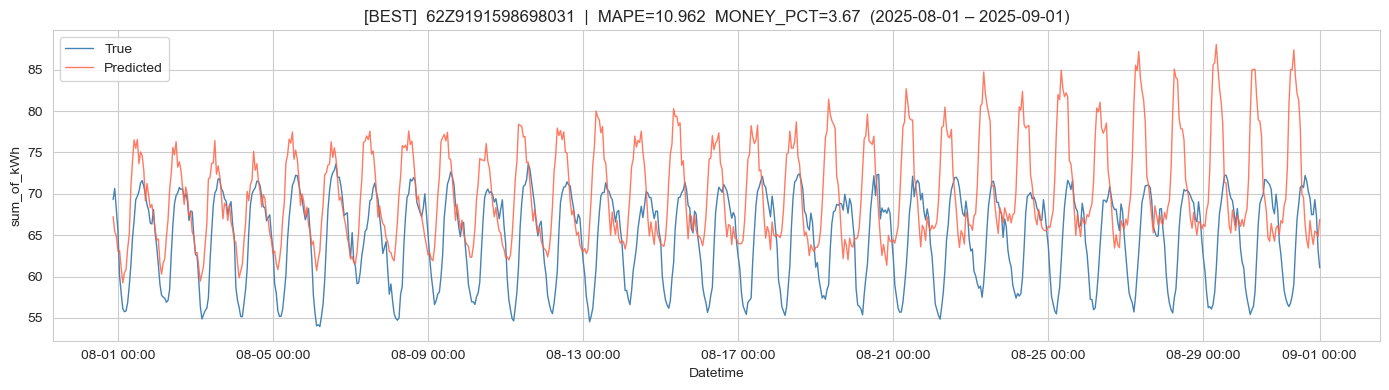

Worst station (SMAPE): 62Z6035944504754


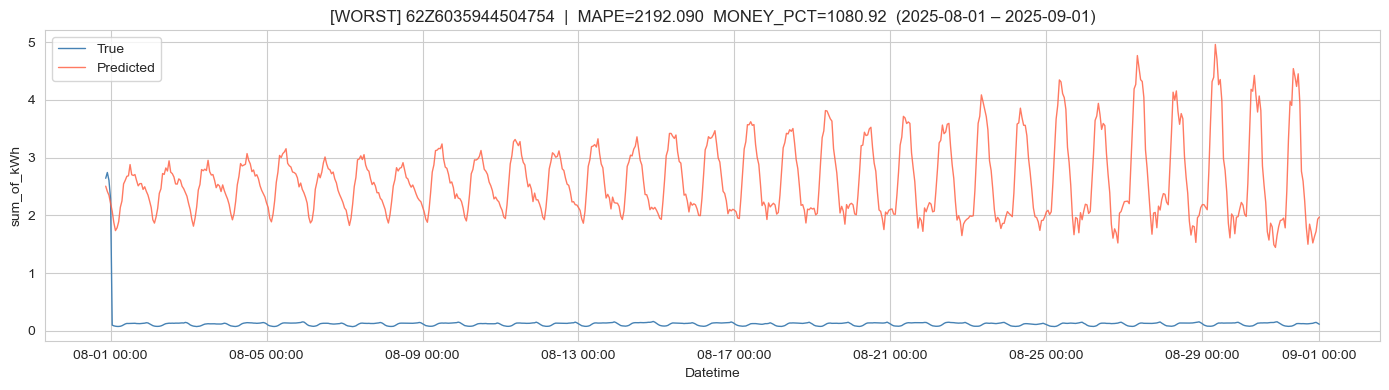

In [27]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")